In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

path = "/content/drive/MyDrive/SER_Project/"

X = np.load(path + "X_fixed_final.npy")
y = np.load(path + "y_fixed_final.npy")

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

X shape: (4852, 128, 128)
y shape: (4852,)
X dtype: float32
y dtype: int64


In [4]:
print("First sample X:\n", X[0])
print("First label y:", y[0])

First sample X:
 [[-80.       -80.       -80.       ... -80.       -80.       -80.      ]
 [-80.       -80.       -80.       ... -80.       -80.       -80.      ]
 [-80.       -80.       -80.       ... -80.       -80.       -80.      ]
 ...
 [-80.       -76.996635 -80.       ... -80.       -80.       -80.      ]
 [-80.       -80.       -80.       ... -80.       -80.       -80.      ]
 [-75.21531  -79.602135 -80.       ... -80.       -80.       -80.      ]]
First label y: 2


===== BASIC INFO =====
X shape: (4852, 128, 128)
y shape: (4852,)
X dtype: float32
y dtype: int64

===== SAMPLE DATA =====
First sample shape: (128, 128)
First label: 2

===== LABEL INFO =====
Unique labels: [0 1 2 3 4 5 6 7]
Number of classes: 8

===== CLASS DISTRIBUTION =====
Class 0: 588 samples
Class 1: 376 samples
Class 2: 776 samples
Class 3: 776 samples
Class 4: 776 samples
Class 5: 776 samples
Class 6: 192 samples
Class 7: 592 samples

===== VALUE RANGE =====
Min value: -80.0
Max value: 0.0
Mean value: -43.337788

===== DATA SANITY CHECK =====
NaN values: 0
Inf values: 0

===== DATA SLICE =====
First 2 samples:
 [[[-80.       -80.       -80.       ... -80.       -80.       -80.      ]
  [-80.       -80.       -80.       ... -80.       -80.       -80.      ]
  [-80.       -80.       -80.       ... -80.       -80.       -80.      ]
  ...
  [-80.       -76.996635 -80.       ... -80.       -80.       -80.      ]
  [-80.       -80.       -80.       ... -80.       -80.       -80.    

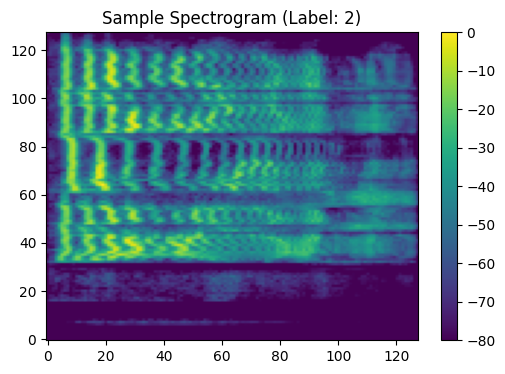


===== CNN INPUT CHECK =====
Updated X shape (for CNN): (4852, 128, 128)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 🔹 1. Basic Info
# ================================
print("===== BASIC INFO =====")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

# ================================
# 🔹 2. Sample Check
# ================================
print("\n===== SAMPLE DATA =====")
print("First sample shape:", X[0].shape)
print("First label:", y[0])

# ================================
# 🔹 3. Label Check
# ================================
print("\n===== LABEL INFO =====")
unique_labels = np.unique(y)
print("Unique labels:", unique_labels)
print("Number of classes:", len(unique_labels))

# ================================
# 🔹 4. Class Distribution
# ================================
print("\n===== CLASS DISTRIBUTION =====")
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

# ================================
# 🔹 5. Value Range Check
# ================================
print("\n===== VALUE RANGE =====")
print("Min value:", X.min())
print("Max value:", X.max())
print("Mean value:", X.mean())

# ================================
# 🔹 6. NaN / Inf Check
# ================================
print("\n===== DATA SANITY CHECK =====")
print("NaN values:", np.isnan(X).sum())
print("Inf values:", np.isinf(X).sum())

# ================================
# 🔹 7. Small Slice View
# ================================
print("\n===== DATA SLICE =====")
print("First 2 samples:\n", X[:2])
print("First 10 labels:", y[:10])

# ================================
# 🔹 8. Visualize Spectrogram
# ================================
print("\n===== VISUALIZATION =====")

plt.figure(figsize=(6,4))
plt.imshow(X[0], aspect='auto', origin='lower')
plt.title(f"Sample Spectrogram (Label: {y[0]})")
plt.colorbar()
plt.show()

# ================================
# 🔹 9. CNN Compatibility Check
# ================================
print("\n===== CNN INPUT CHECK =====")

# if len(X.shape) == 3:
#     print("Adding channel dimension for CNN...")
#     X = X[..., np.newaxis]

print("Updated X shape (for CNN):", X.shape)

In [6]:
from sklearn.model_selection import train_test_split
# ================================
# 🔹 3. Reshape for Conv1D
# ================================
# Already (samples, mel, time) → we transpose

# X = np.transpose(X, (0, 2, 1))
# Now: (samples, time_steps=128, features=128)

print("Reshaped X:", X.shape)

# ================================
# 🔹 4. Train/Val Split
# ================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Reshaped X: (4852, 128, 128)


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = 8

model_npy = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation="softmax"),
])

In [8]:
# ================================
# 🔹 6. Compile
# ================================
model_npy.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_npy.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,512 (24.86 MB)

 Trainable params: 6,517,512 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ================================
# 🔹 7. Train
# ================================
history_npy = model_npy.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True,
        )
    ],
)


Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.2486 - loss: 2.5514 - val_accuracy: 0.3821 - val_loss: 1.5570
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3522 - loss: 1.5795 - val_accuracy: 0.4295 - val_loss: 1.4780
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4051 - loss: 1.4735 - val_accuracy: 0.4501 - val_loss: 1.4072
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4476 - loss: 1.4158 - val_accuracy: 0.5417 - val_loss: 1.3127
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4860 - loss: 1.3265 - val_accuracy: 0.5448 - val_loss: 1.2403
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5347 - loss: 1.2435 - val_accuracy: 0.5994 - val_loss: 1.1539
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5553 - loss: 1.1772 - val_accuracy: 0.6035 - val_loss: 1.1040
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5821 - loss: 1.1129 - val_accuracy: 

In [10]:
# ================================
# 🔹 8. Evaluate
# ================================
loss, acc = model_npy.evaluate(X_val, y_val)
print(f"Validation Accuracy: {acc:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8682 - loss: 0.4043
Validation Accuracy: 0.8682


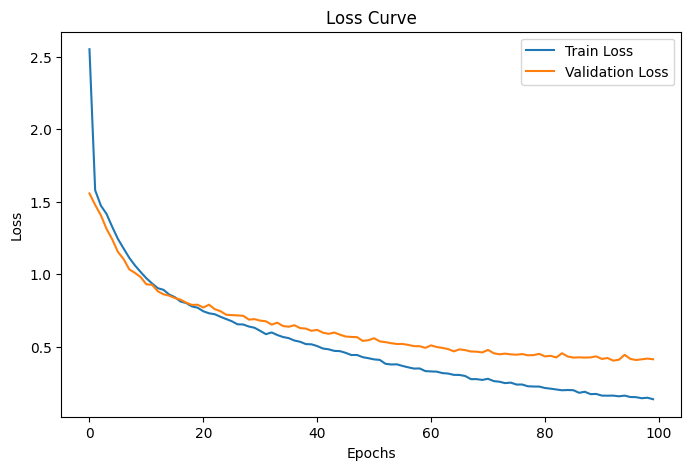

In [11]:
import matplotlib.pyplot as plt

history = model_npy.history  # if stored directly
# OR if using history variable:
history = history.history
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

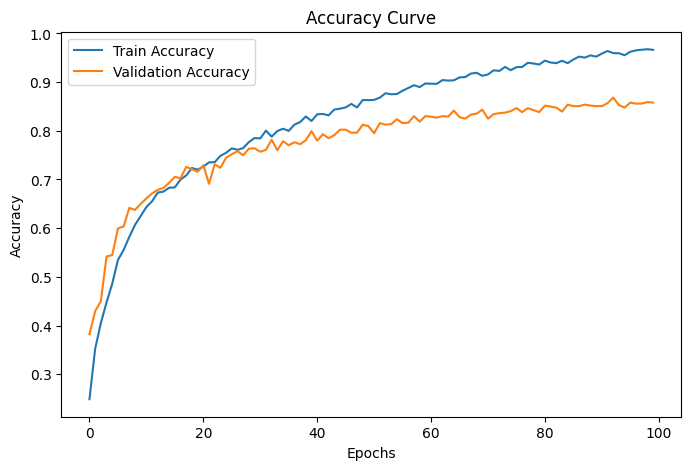

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns


y_pred = np.argmax(model_npy.predict(X_val), axis=1)
print(classification_report(y_val, y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       118
           1       0.80      0.84      0.82        75
           2       0.91      0.87      0.89       155
           3       0.83      0.85      0.84       155
           4       0.87      0.96      0.91       155
           5       0.92      0.81      0.86       155
           6       0.65      0.62      0.63        39
           7       0.86      0.92      0.89       119

    accuracy                           0.87       971
   macro avg       0.85      0.84      0.84       971
weighted avg       0.87      0.87      0.87       971



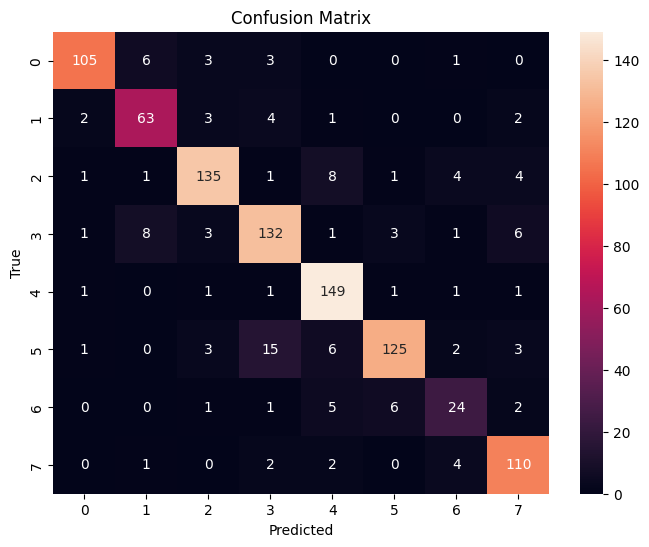

In [14]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()